Principal Component Analysis (PCA)- Réduction de dimension

https://builtin.com/machine-learning/pca-in-python

In [5]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np




**Reduction de dimension**

Pour visualiser et pour accélerer ML

https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.PCA.html

Reduction du nombre des attributs "features" en les "agrégeant". Le but est d'accélérer l'apprentissage et de visualiser les données

**IRIS dataset**

In [10]:
from sklearn.datasets import load_iris
iris = load_iris()
X_iris = iris.data
y_iris = iris.target

In [12]:
from sklearn.decomposition import PCA


pca = PCA(n_components=2)
pca.fit(X_iris)
X_iris_pca= pca.transform(X_iris)
#pca.fit_transform(X_iris)

print( "2 premières lignes originales:\n")
print(X_iris[:2])
print( "\n 2 premières lignes transformées:\n")
print(pca.transform(X_iris)[:2])
print( "\n 2 premières lignes transformées:\n")
print(X_iris_pca[:2])
print( "\n 2 premières lignes originales:\n")
print(pca.inverse_transform(X_iris_pca)[:2])

2 premières lignes originales:

[[5.1 3.5 1.4 0.2]
 [4.9 3.  1.4 0.2]]

 2 premières lignes transformées:

[[-2.68412563  0.31939725]
 [-2.71414169 -0.17700123]]

 2 premières lignes transformées:

[[-2.68412563  0.31939725]
 [-2.71414169 -0.17700123]]

 2 premières lignes originales:

[[5.08303897 3.51741393 1.40321372 0.21353169]
 [4.7462619  3.15749994 1.46356177 0.24024592]]


Qualité d'agrégation

In [15]:
#les variances

pca.explained_variance_ratio_

array([0.92461872, 0.05306648])

In [17]:
pca.explained_variance_ratio_.sum()

0.9776852063187962


Réduction pour le dataset IRIS

In [20]:
X_pca = pca.transform(X_iris)

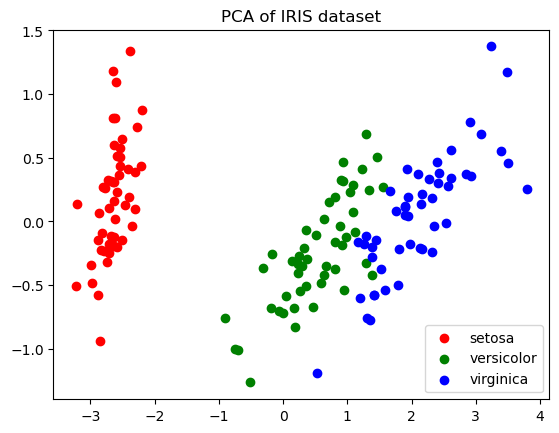

In [22]:
import matplotlib.pyplot as plt

plt.figure()
for c, i, target_name in zip("rgb", [0, 1, 2], iris.target_names):
   plt.scatter(X_pca[y_iris==i,0], X_pca[y_iris==i,1], c=c, label=target_name)
plt.legend()
plt.title('PCA of IRIS dataset')

plt.show()

In [24]:
#Les attributs pour la première donnée
print(X_iris[0,:])

[5.1 3.5 1.4 0.2]


In [26]:
#Retrouver la première donnée après agrégation
print(X_pca[0,:])
      
print(pca.inverse_transform(X_pca[0,:]))

[-2.68412563  0.31939725]
[5.08303897 3.51741393 1.40321372 0.21353169]


In [28]:
pca = PCA(n_components=2)
pca.fit(X_iris)
pca.transform(X_iris)

print("explained_variance_ratio {} ".format(pca.explained_variance_ratio_))

print ("explained_variance_ratio_.sum {}".format(pca.explained_variance_ratio_.sum()))

explained_variance_ratio [0.92461872 0.05306648] 
explained_variance_ratio_.sum 0.9776852063187962


In [30]:
pca = PCA(n_components=3)
pca.fit(X_iris)
pca.transform(X_iris)

print("explained_variance_ratio {} ".format(pca.explained_variance_ratio_))

print ("explained_variance_ratio_.sum {}".format(pca.explained_variance_ratio_.sum()))

explained_variance_ratio [0.92461872 0.05306648 0.01710261] 
explained_variance_ratio_.sum 0.9947878161267255


In [32]:
pca = PCA(n_components=4)
pca.fit(X_iris)
pca.transform(X_iris)


print("explained_variance_ratio {} ".format(pca.explained_variance_ratio_))

print ("explained_variance_ratio_.sum {}".format(pca.explained_variance_ratio_.sum()))


explained_variance_ratio [0.92461872 0.05306648 0.01710261 0.00521218] 
explained_variance_ratio_.sum 1.0


In [34]:
pca = PCA(n_components=2)
pca.fit(X_iris)
X_iris_pca = pca.transform(X_iris)



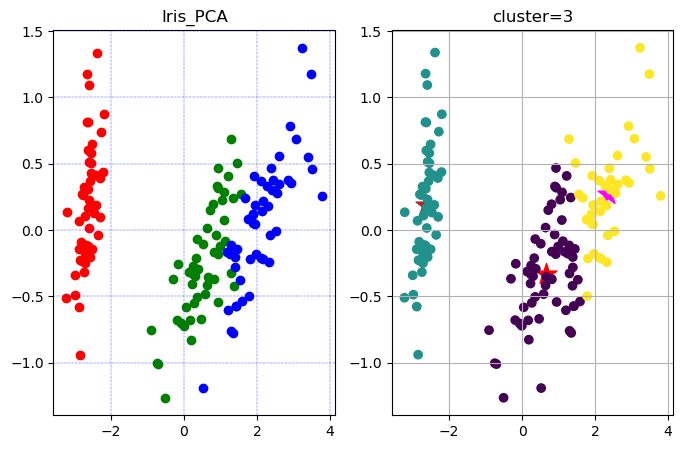

In [36]:


f,(f1, f2) = plt.subplots(1, 2, figsize=(8,5))

#Première figure, f1
f1.set_title('Iris_PCA')

for c, i, target_name in zip("rgb", [0, 1, 2], iris.target_names):
   f1.scatter(X_pca[y_iris==i,0], X_pca[y_iris==i,1], c=c, label=target_name)

f1.grid(color='b', ls = '-.', lw = 0.25)
#On fait clustering
from sklearn.cluster import KMeans
model = KMeans(n_clusters=3)

model.fit(X_iris_pca)

#2ème figure, f2
f2.set_title("cluster=3")

f2.scatter(model.cluster_centers_[0,0], model.cluster_centers_[0,1], s=250, c='red',
                                         marker='*', label='center 0')
f2.scatter(model.cluster_centers_[1,0], model.cluster_centers_[1,1], s=250, c='brown',
                                        marker='*', label='center 1')
f2.scatter(model.cluster_centers_[2,0], model.cluster_centers_[2,1], s=250, c='magenta',
                                        marker='*', label='center 2')
f2.scatter(X_iris_pca[:,0], X_iris_pca[:,1],c=model.labels_)
f2.grid()
#f2.scatter(X_iris_pca[:,0], X_iris_pca[:,1], c = model.labels_)
#f2.scatter(model.cluster_centers_[:, 0], model.cluster_centers_[:, 1],
#           s=150,marker='*', c='red')
plt.show(block=True)